# SWE-ContextBench 数据探索

- 论文：[SWE Context Bench: A Benchmark for Context Learning in Coding](https://arxiv.org/abs/2602.08316) (arXiv:2602.08316)
- 数据集：[`jiayuanz3/SWEContextBench`](https://huggingface.co/datasets/jiayuanz3/SWEContextBench)
- 评测代码：https://github.com/jiayuanz3/SWEContextBench

## 这个 benchmark 在测什么

普通的 SWE-bench 把每个 issue 当成**独立**任务。SWE-ContextBench 的出发点是：真实项目里的 issue 是**有关联**的 —— 同一个 repo 里，一个新 PR 常常引用、依赖之前的某个 PR。

于是数据被拆成两半：

| 文件 | 行数 | 角色 |
|---|---|---|
| `SWEContextBench_Experience.parquet` | 1100 | **经验池**（base tasks）。先跑这些，把解题过程沉淀成"经验"（摘要 / 索引 / memory）。 |
| `SWEContextBench_Related.parquet` | 376 | **待测任务**（related tasks）。跑这些时允许 agent 去经验池里检索。 |
| `SWEContextBench_Relationship.parquet` | 376 | 关系表：哪个 related 任务对应哪个 experience 任务。 |
| `SWEContextBench_Lite_Experience.parquet` | 300 | 经验池的小规模子集。 |
| `SWEContextBench_Related_Lite.parquet` | 99 | 待测任务的小规模子集。 |

评测的不只是"解没解对"，还有**效率**：用了对的历史经验，应该更准 + 更省 token + 更快；而塞入无关的上下文则应该没有收益甚至变差。

单个 task instance 的字段沿用 SWE-bench 惯例，完全兼容。

> 本 notebook 只做数据理解，不跑评测。跑评测见最后一节。

## 0. 环境

In [1]:
import ast
import json
import re
import textwrap
from collections import Counter
from pathlib import Path

import pandas as pd

pd.set_option("display.max_colwidth", 120)

DATA = Path.cwd() / "data"      # parquet 文件在 notebook 同级的 data/ 子目录下
assert DATA.is_dir(), f"找不到 {DATA}，请在 notebook 所在目录启动 jupyter"

sorted(p.name for p in DATA.glob("*.parquet"))

['SWEContextBench_Experience.parquet',
 'SWEContextBench_Lite_Experience.parquet',
 'SWEContextBench_Related.parquet',
 'SWEContextBench_Related_Lite.parquet',
 'SWEContextBench_Relationship.parquet']

## 1. 载入五张表

In [2]:
experience      = pd.read_parquet(DATA / "SWEContextBench_Experience.parquet")
related         = pd.read_parquet(DATA / "SWEContextBench_Related.parquet")
relationship    = pd.read_parquet(DATA / "SWEContextBench_Relationship.parquet")
experience_lite = pd.read_parquet(DATA / "SWEContextBench_Lite_Experience.parquet")
related_lite    = pd.read_parquet(DATA / "SWEContextBench_Related_Lite.parquet")

for name, df in [("experience", experience), ("related", related),
                 ("relationship", relationship),
                 ("experience_lite", experience_lite), ("related_lite", related_lite)]:
    print(f"{name:<16} {df.shape[0]:>5} rows x {df.shape[1]} cols")

print()
print("任务表字段:", list(experience.columns))
print("关系表字段:", list(relationship.columns))

experience        1100 rows x 12 cols
related            376 rows x 12 cols
relationship       376 rows x 6 cols
experience_lite    300 rows x 12 cols
related_lite        99 rows x 12 cols

任务表字段: ['repo', 'instance_id', 'base_commit', 'patch', 'test_patch', 'problem_statement', 'hints_text', 'created_at', 'version', 'FAIL_TO_PASS', 'PASS_TO_PASS', 'environment_setup_commit']
关系表字段: ['related_instance_id', 'related_pr_url', 'related_issue_url', 'experience_instance_id', 'experience_pr_url', 'experience_issue_url']


### 1.1 五张表的体量

「大小」有好几种口径，这里都算一遍：

- **磁盘 / 内存** —— 存得下吗
- **行数 / 唯一 instance 数** —— 有多少道题（注意重复 id，见 §2.2）
- **文本体量** —— 真正决定 agent 上下文开销的是这个

In [3]:
FILES = {
    "Experience":      ("SWEContextBench_Experience.parquet",      experience),
    "Related":         ("SWEContextBench_Related.parquet",         related),
    "Relationship":    ("SWEContextBench_Relationship.parquet",    relationship),
    "Lite_Experience": ("SWEContextBench_Lite_Experience.parquet", experience_lite),
    "Related_Lite":    ("SWEContextBench_Related_Lite.parquet",    related_lite),
}

rows = []
for name, (fn, df) in FILES.items():
    rows.append({
        "表": name,
        "parquet(MB)": round((DATA / fn).stat().st_size / 1e6, 2),
        "行数": len(df),
        "唯一id": df["instance_id"].nunique() if "instance_id" in df.columns else None,
        "列数": df.shape[1],
        "内存(MB)": round(df.memory_usage(deep=True).sum() / 1e6, 1),
    })

sizes = pd.DataFrame(rows)
print(sizes.to_string(index=False))
print(f"\n五个 parquet 合计: {sizes['parquet(MB)'].sum():.2f} MB")

              表  parquet(MB)   行数   唯一id  列数  内存(MB)
     Experience         4.03 1100 1007.0  12    14.7
        Related         2.25  376  357.0  12    11.3
   Relationship         0.02  376    NaN   6     0.1
Lite_Experience         1.12  300  300.0  12     3.5
   Related_Lite         0.54   99   99.0  12     2.0

五个 parquet 合计: 7.96 MB


In [4]:
# 文本体量：各字段的总字符数
TEXT_COLS = ["problem_statement", "patch", "test_patch", "hints_text",
             "FAIL_TO_PASS", "PASS_TO_PASS"]

TASK_TABLES = ["Experience", "Related", "Lite_Experience", "Related_Lite"]


def text_volume(df):
    return pd.Series({c: int(df[c].astype("string").fillna("").str.len().sum())
                      for c in TEXT_COLS})


vol = pd.DataFrame({name: text_volume(FILES[name][1]) for name in TASK_TABLES})

print("各字段总字符数（单位：百万字符）")
print((vol / 1e6).round(2).to_string())
print()
print("每张表合计（百万字符）")
print((vol.sum() / 1e6).round(2).to_string())

各字段总字符数（单位：百万字符）
                   Experience  Related  Lite_Experience  Related_Lite
problem_statement        2.01     0.66             0.50          0.18
patch                    2.28     2.46             0.31          0.41
test_patch               2.05     2.20             0.50          0.35
hints_text               1.21     0.39             0.48          0.07
FAIL_TO_PASS             0.22     0.13             0.08          0.04
PASS_TO_PASS             6.66     5.33             1.60          0.95

每张表合计（百万字符）
Experience         14.42
Related            11.16
Lite_Experience     3.46
Related_Lite        1.99


In [5]:
# 粗估 token 规模。没装 tokenizer，按代码/英文混合约 4 字符 ≈ 1 token 估算，
# 只用来看数量级，别当精确值。
CHARS_PER_TOKEN = 4

print("把整张表的文本全部塞进上下文的规模（粗估）:")
for name in TASK_TABLES:
    df = FILES[name][1]
    total = vol[name].sum()
    print(f"  {name:<16} {total/1e6:>6.2f} M 字符  ≈ {total/CHARS_PER_TOKEN/1e6:>5.2f} M tokens"
          f"    平均每任务 ≈ {total/len(df)/CHARS_PER_TOKEN:>7.0f} tokens")

print()
print("单个任务真正喂给 agent 的题面（problem_statement + hints_text）平均规模:")
for name in ["Experience", "Related"]:
    df = FILES[name][1]
    n = (df["problem_statement"].astype("string").fillna("").str.len()
         + df["hints_text"].astype("string").fillna("").str.len()).mean()
    print(f"  {name:<16} ≈ {n:>6.0f} 字符 ≈ {n/CHARS_PER_TOKEN:>5.0f} tokens")

print()
print("注意：这些数字不含仓库源码。agent 真正的上下文开销主要来自读代码，")
print("     这里的题面只是入口，实际 token 消耗会高出一到两个数量级。")

把整张表的文本全部塞进上下文的规模（粗估）:
  Experience        14.42 M 字符  ≈  3.61 M tokens    平均每任务 ≈    3278 tokens
  Related           11.16 M 字符  ≈  2.79 M tokens    平均每任务 ≈    7422 tokens
  Lite_Experience    3.46 M 字符  ≈  0.87 M tokens    平均每任务 ≈    2884 tokens
  Related_Lite       1.99 M 字符  ≈  0.50 M tokens    平均每任务 ≈    5033 tokens

单个任务真正喂给 agent 的题面（problem_statement + hints_text）平均规模:
  Experience       ≈   2925 字符 ≈   731 tokens
  Related          ≈   2788 字符 ≈   697 tokens

注意：这些数字不含仓库源码。agent 真正的上下文开销主要来自读代码，
     这里的题面只是入口，实际 token 消耗会高出一到两个数量级。


## 2. 一个 task instance 长什么样

先只看结构 —— 每个字段的类型和长度，不打印正文。

In [6]:
row = related.iloc[1]

for col in related.columns:
    v = row[col]
    s = str(v)
    preview = s if len(s) <= 100 else s[:97].replace("\n", " ") + "..."
    # preview = s
    # print("\n#####")
    print(f"{col:<25} {type(v).__name__:<8} len={len(s):>7}  {preview}")

repo                      str      len=     15  astropy/astropy
instance_id               str      len=     21  astropy__astropy-4973
base_commit               str      len=     40  d5bd3f68bb6d5ce3a61bdce9883ee750d1afade5
patch                     str      len=   1285  diff --git a/CHANGES.rst b/CHANGES.rst index 3070a53b20ff..9fef40d4a311 100644 --- a/CHANGES.rst ...
test_patch                str      len=    892  diff --git a/astropy/wcs/tests/test_wcs.py b/astropy/wcs/tests/test_wcs.py index 85853e10e556..39...
problem_statement         str      len=   2380  Don't raise an error if passing zero coordinates to WCS Currently, passing a (0,2) shaped array t...
hints_text                str      len=     84  I've run into this again in a different context (spectra) - this is a real bug IMHO.
created_at                str      len=     20  2018-08-20T14:07:20Z
version                   str      len=      3  3.1
FAIL_TO_PASS              str      len=     55  ["astropy/wcs/tests/test_wcs

### ⚠️ 坑一：`FAIL_TO_PASS` / `PASS_TO_PASS` 的格式不统一

数据卡说这两个字段是 "a json list of strings"。**实际上只有约 3/4 的行是合法 JSON。**
其余是 Python `repr()` 出来的字符串（单引号），其中一部分还是 **numpy 数组的 repr** —— 元素之间没有逗号，只有换行：

```
"['a.b.TestX#testDiv'\n 'a.b.TestX#testQuotient']"
```

这种连 `ast.literal_eval` 都会解析错（被当成隐式字符串拼接，两个测试名会粘成一个）。
所以下面用一个三级回退的解析器，后面所有涉及这两个字段的地方都走它。

In [7]:
QUOTED = re.compile("'([^']*)'|\"([^\"]*)\"")


def parse_tests(v):
    '''把 FAIL_TO_PASS / PASS_TO_PASS 解析成 list[str]。兼容 JSON / Python repr / numpy repr。'''
    if v is None:
        return []
    if isinstance(v, (list, tuple)):
        return [str(x) for x in v]
    s = str(v).strip()
    if not s:
        return []

    # 1) 标准 JSON
    try:
        out = json.loads(s)
        if isinstance(out, list):
            return [str(x) for x in out]
    except Exception:
        pass

    # 2) Python 字面量（单引号 list）。但 numpy repr 缺逗号会被误解析成字符串拼接，
    #    用「引号片段数」和「解析出的元素数」是否一致来识别这种情况。
    try:
        out = ast.literal_eval(s)
        if isinstance(out, (list, tuple)) and all(isinstance(x, str) for x in out):
            if len(out) == len(QUOTED.findall(s)):
                return list(out)
    except Exception:
        pass

    # 3) 兜底：直接抠出所有被引号包住的片段
    return [a or b for a, b in QUOTED.findall(s)]


def is_json_list(v):
    try:
        return isinstance(json.loads(str(v)), list)
    except Exception:
        return False


for df, name in [(experience, "experience"), (related, "related")]:
    for col in ["FAIL_TO_PASS", "PASS_TO_PASS"]:
        n = sum(1 for v in df[col] if is_json_list(v))
        print(f"{name:<12} {col:<14} {n:>5}/{len(df):<5} 行是合法 JSON  (其余 {len(df)-n} 行是 repr)")

print()
bad = next(v for v in experience["FAIL_TO_PASS"] if not is_json_list(v))
print("一个非 JSON 的例子:")
print("  raw    :", repr(bad)[:170])
print("  解析后 :", parse_tests(bad))

experience   FAIL_TO_PASS     805/1100  行是合法 JSON  (其余 295 行是 repr)
experience   PASS_TO_PASS     825/1100  行是合法 JSON  (其余 275 行是 repr)
related      FAIL_TO_PASS     265/376   行是合法 JSON  (其余 111 行是 repr)
related      PASS_TO_PASS     268/376   行是合法 JSON  (其余 108 行是 repr)

一个非 JSON 的例子:
  raw    : "['org.apache.druid.query.aggregation.post.ArithmeticPostAggregatorTest#testPow']"
  解析后 : ['org.apache.druid.query.aggregation.post.ArithmeticPostAggregatorTest#testPow']


### ⚠️ 坑二：`instance_id` 有重复行

`Experience` 和 `Related` 两张表里都有重复的 `instance_id`。
如果直接 `set_index("instance_id")` 再 `.loc[...]`，取出来的会是 DataFrame 而不是 Series，
后续代码会莫名其妙地炸。**建索引前先 `drop_duplicates`。**

In [8]:
for name, df in [("experience", experience), ("related", related),
                 ("experience_lite", experience_lite), ("related_lite", related_lite)]:
    n, u = len(df), df["instance_id"].nunique()
    print(f"{name:<16} {n:>5} 行 / {u:>5} 个唯一 id   (重复 {n - u})")

dup_ids = related["instance_id"][related["instance_id"].duplicated()].unique()
print()
print("related 中重复的 id 示例:", list(dup_ids[:5]))

d = related[related["instance_id"].isin(dup_ids)]
print("这些重复行在所有列上也完全相同:", len(d.drop_duplicates()) == d["instance_id"].nunique())

# 不完全相同的话，差在哪些列？
g = d.groupby("instance_id")
diff_cols = [c for c in d.columns if (g[c].nunique(dropna=False) > 1).any()]
print("同一个 id 的不同行，在这些列上取值不同:", diff_cols)

experience        1100 行 /  1007 个唯一 id   (重复 93)
related            376 行 /   357 个唯一 id   (重复 19)
experience_lite    300 行 /   300 个唯一 id   (重复 0)
related_lite        99 行 /    99 个唯一 id   (重复 0)

related 中重复的 id 示例: ['astropy__astropy-15082', 'django__django-11776', 'django__django-27858', 'django__django-27910', 'django__django-28147']
这些重复行在所有列上也完全相同: False
同一个 id 的不同行，在这些列上取值不同: ['base_commit', 'patch', 'test_patch', 'problem_statement', 'created_at', 'version', 'FAIL_TO_PASS', 'PASS_TO_PASS', 'environment_setup_commit']


注意：同一个 `instance_id` 的多行**内容并不完全相同**。所以 `drop_duplicates(subset="instance_id")`
是"保留第一条"，不是"去掉冗余"。如果你要做严肃的评测，得先搞清楚哪一条才是权威版本
（可以去对照上游的 SWE-bench Lite / Verified / Multilingual）。本 notebook 只为浏览方便，取第一条。

### 2.2 把重复的 instance 抓出来看

上面只知道"有重复且内容不同"，这一格把同一个 `instance_id` 的多行并排打出来，
逐列标注哪些字段相同、哪些不同，直接看到差异到底长什么样。

In [9]:
def duplicate_groups(df):
    '''返回 {instance_id: 该 id 对应的所有行}，只含出现多次的 id。'''
    dup_ids = df["instance_id"][df["instance_id"].duplicated()].unique()
    return {iid: df[df["instance_id"] == iid] for iid in dup_ids}


def differing_cols(g):
    '''一组里取值不同的列。

    注意：不能写成 g[c].nunique() > 1 —— nunique() 默认 dropna=True，
    「一行有值、另一行是 NaN」会被当成只有一个唯一值，从而漏报。
    astype(str) 也救不了：pandas 3.0 的 str dtype 下 NA 仍是 NA，不会变成 "nan"。
    '''
    return [c for c in g.columns if len({str(x) for x in g[c]}) > 1]


def indent(s, pad="        "):
    return ("\n" + pad).join(str(s).splitlines()) or "(空)"


def show_duplicate_group(g, max_chars=500):
    diff = set(differing_cols(g))
    print("#" * 100)
    print(f"# {g.iloc[0]['instance_id']}    repo={g.iloc[0]['repo']}    "
          f"出现 {len(g)} 次    (行号 {list(g.index)})")
    print("#" * 100)

    for col in g.columns:
        vals = [str(v) for v in g[col]]
        if col not in diff:
            s = vals[0].replace("\n", " ")
            print(f"  [同] {col:<24} {s[:90]}{'...' if len(s) > 90 else ''}")
        else:
            print(f"  [异] {col:<24} 长度 {[len(v) for v in vals]}")
            for i, s in zip(g.index, vals):
                body = s if len(s) <= max_chars else s[:max_chars] + f"\n... [截断，共 {len(s)} 字符]"
                print(f"    行 {i}:")
                print("        " + indent(body))
            print()
    print()


groups = duplicate_groups(related)
print(f"related 表里有 {len(groups)} 个 instance_id 出现多次\n")

for iid, g in groups.items():
    print(f"  {iid:<34} x{len(g)}  差异列: {differing_cols(g)}")


related 表里有 19 个 instance_id 出现多次

  astropy__astropy-15082             x2  差异列: ['problem_statement', 'version', 'PASS_TO_PASS']
  django__django-11776               x2  差异列: ['problem_statement', 'version', 'FAIL_TO_PASS', 'PASS_TO_PASS']
  django__django-27858               x2  差异列: ['problem_statement', 'version']
  django__django-27910               x2  差异列: ['problem_statement', 'version', 'FAIL_TO_PASS']
  django__django-28147               x2  差异列: ['base_commit', 'patch', 'test_patch', 'problem_statement', 'created_at', 'version', 'FAIL_TO_PASS', 'PASS_TO_PASS', 'environment_setup_commit']
  django__django-28862               x2  差异列: ['problem_statement', 'version', 'FAIL_TO_PASS', 'PASS_TO_PASS']
  django__django-28916               x2  差异列: ['problem_statement', 'version', 'FAIL_TO_PASS', 'PASS_TO_PASS']
  django__django-29123               x2  差异列: ['problem_statement', 'version', 'FAIL_TO_PASS', 'PASS_TO_PASS']
  django__django-29124               x2  差异列: ['problem_state

In [10]:
# 挑差异最"轻"的一组细看
by_diff = sorted(groups.items(), key=lambda kv: len(differing_cols(kv[1])))

show_duplicate_group(by_diff[0][1])


####################################################################################################
# scikit-learn__scikit-learn-25365    repo=scikit-learn/scikit-learn    出现 2 次    (行号 [64, 319])
####################################################################################################
  [同] repo                     scikit-learn/scikit-learn
  [同] instance_id              scikit-learn__scikit-learn-25365
  [同] base_commit              f45a9071e1ff2bdc044c040959b5387c3d9559c8
  [同] patch                    diff --git a/doc/whats_new/v1.2.rst b/doc/whats_new/v1.2.rst index ef30d378bb2c4..aa3ed3c0...
  [同] test_patch               diff --git a/sklearn/manifold/tests/test_t_sne.py b/sklearn/manifold/tests/test_t_sne.py i...
...
 Best fix might ...
  [同] created_at               2023-01-12T14:13:46Z
  [异] version                  长度 [3, 3]
    行 64:
        1.3
    行 319:
        nan

  [同] FAIL_TO_PASS             ["sklearn/manifold/tests/test_t_sne.py::test_tsne_works_with_pan

In [11]:
# 再看差异最"重"的一组：连 patch 和 problem_statement 都不一样
show_duplicate_group(by_diff[-1][1], max_chars=700)

####################################################################################################
# django__django-28147    repo=django/django    出现 2 次    (行号 [13, 241])
####################################################################################################
  [同] repo                     django/django
  [同] instance_id              django__django-28147
  [异] base_commit              长度 [40, 40]
    行 13:
        4b4e68a7a6847e8b449923bb882bed01f0d7b2a8
    行 241:
        9d6f981a66bd2c4188c4a3e08e4f36fc9c4882ef

  [异] patch                    长度 [2707, 3444]
    行 13:
        diff --git a/django/db/models/fields/related.py b/django/db/models/fields/related.py
        index 56cee83a5e8e..f6c5ae258597 100644
        --- a/django/db/models/fields/related.py
        +++ b/django/db/models/fields/related.py
        @@ -19,9 +19,9 @@
         from . import Field
         from .mixins import FieldCacheMixin
         from .related_descriptors import (
        -    ForwardManyT

In [12]:
# experience 表里也一样，看一组
exp_groups = duplicate_groups(experience)
print(f"experience 表里有 {len(exp_groups)} 个 instance_id 出现多次\n")
show_duplicate_group(next(iter(exp_groups.values())))

experience 表里有 93 个 instance_id 出现多次

####################################################################################################
# astropy__astropy-12907    repo=astropy/astropy    出现 2 次    (行号 [0, 600])
####################################################################################################
  [同] repo                     astropy/astropy
  [同] instance_id              astropy__astropy-12907
  [同] base_commit              d16bfe05a744909de4b27f5875fe0d4ed41ce607
  [同] patch                    diff --git a/astropy/modeling/separable.py b/astropy/modeling/separable.py --- a/astropy/m...
  [同] test_patch               diff --git a/astropy/modeling/tests/test_separable.py b/astropy/modeling/tests/test_separa...
  [同] problem_statement        Modeling's `separability_matrix` does not compute separability correctly for nested Compou...
  [同] hints_text               nan
  [同] created_at               2022-03-03T15:14:54Z
  [同] version                  4.3
  [同] FAIL_TO_

### 2.1 完整打印一个 instance

下面的 helper 把一个 task 的每个字段完整展开。这是理解数据最直接的方式 ——
一个 instance 本质上就是：

> **在 `base_commit` 这个提交上，给你一段 issue 描述（`problem_statement`），
> 要你写出 `patch`，使得 `FAIL_TO_PASS` 里的测试从红变绿，
> 同时 `PASS_TO_PASS` 里的测试保持绿。**

`test_patch` 是官方提供的测试代码（评测时会强制打上，防止 agent 改测试作弊），
`hints_text` 是 PR 提交前 issue 下面的讨论。

In [13]:
def show_instance(row, max_chars=2500, fields=None):
    '''完整展示一个 task instance。max_chars=None 表示不截断。'''
    for col in (fields or list(row.index)):
        v = row[col]
        print("=" * 100)
        print(f"### {col}")
        print("=" * 100)
        if col in ("FAIL_TO_PASS", "PASS_TO_PASS"):
            tests = parse_tests(v)
            print(f"({len(tests)} 个测试)")
            for t in tests[:20]:
                print("  -", t)
            if len(tests) > 20:
                print(f"  ... 还有 {len(tests) - 20} 个")
        else:
            s = str(v)
            if max_chars is not None and len(s) > max_chars:
                print(s[:max_chars])
                print(f"\n... [截断，本字段共 {len(s)} 字符]")
            else:
                print(s)
        print()


show_instance(row)

### repo
astropy/astropy

### instance_id
astropy__astropy-4973

### base_commit
d5bd3f68bb6d5ce3a61bdce9883ee750d1afade5

### patch
diff --git a/CHANGES.rst b/CHANGES.rst
index 3070a53b20ff..9fef40d4a311 100644
--- a/CHANGES.rst
+++ b/CHANGES.rst
@@ -1269,6 +1269,8 @@ astropy.vo
 astropy.wcs
 ^^^^^^^^^^^
 
+- Instead of raising an error ``astropy.wcs`` now returns the input when
+  the input has zero size.                                       [#7746]
 
 Other Changes and Additions
 ---------------------------
diff --git a/astropy/wcs/wcs.py b/astropy/wcs/wcs.py
index d3a06f2b3176..6afe18a9e24c 100644
--- a/astropy/wcs/wcs.py
+++ b/astropy/wcs/wcs.py
@@ -1212,6 +1212,9 @@ def _array_converter(self, func, sky, *args, ra_dec_order=False):
         """
 
         def _return_list_of_arrays(axes, origin):
+            if any([x.size == 0 for x in axes]):
+                return axes
+
             try:
                 axes = np.broadcast_arrays(*axes)
             except ValueError:
@@ -

### 2.3 experience 表（经验池）长什么样

前面看的都是 `related`（待测任务）。这一节看 `experience` —— 1100 行的经验池，
agent 先在这上面跑一遍、把解题过程沉淀成可检索的形式，供 related 任务复用。

字段结构和 related 完全一样，区别在于它的**角色**：它既是经验来源，也是检索时的**干扰池**。

In [14]:
# 元数据概览
print("前 8 行（只看元数据列）:")
print(experience[["instance_id", "repo", "version", "created_at"]].head(8).to_string())

print("\n各文本字段的字符长度（中位数）:")
text_cols = ["problem_statement", "patch", "test_patch", "hints_text"]
lens = pd.DataFrame({c: experience[c].astype("string").fillna("").str.len() for c in text_cols})
print(lens.median().round(0).to_string())

print("\n经验池覆盖的 repo（前 15）:")
print(experience["repo"].value_counts().head(15).to_string())

前 8 行（只看元数据列）:
              instance_id             repo  version            created_at
0  astropy__astropy-12907  astropy/astropy      4.3  2022-03-03T15:14:54Z
1  astropy__astropy-14182  astropy/astropy      5.1  2022-12-16T11:13:37Z
2  astropy__astropy-14365  astropy/astropy      5.1  2023-02-06T19:20:34Z
3  astropy__astropy-14995  astropy/astropy      5.2  2023-06-27T19:48:18Z
4   astropy__astropy-6938  astropy/astropy      1.3  2017-12-07T00:01:14Z
5   astropy__astropy-7746  astropy/astropy      1.3  2018-08-20T14:07:20Z
6    django__django-10914    django/django      3.0  2019-01-30T13:13:20Z
7    django__django-10924    django/django      3.0  2019-02-03T11:30:12Z

各文本字段的字符长度（中位数）:
problem_statement    1210.0
patch                 944.0
test_patch           1265.0
hints_text            240.0

经验池覆盖的 repo（前 15）:
repo
django/django                345
sympy/sympy                  152
sphinx-doc/sphinx             60
matplotlib/matplotlib         57
scikit-learn/scikit-learn     55

In [15]:
# 完整打印一条 experience 任务
exp_row = experience.iloc[0]
print(">>> 这一条是:", exp_row["instance_id"], "\n")
show_instance(exp_row, max_chars=1500)

>>> 这一条是: astropy__astropy-12907 

### repo
astropy/astropy

### instance_id
astropy__astropy-12907

### base_commit
d16bfe05a744909de4b27f5875fe0d4ed41ce607

### patch
diff --git a/astropy/modeling/separable.py b/astropy/modeling/separable.py
--- a/astropy/modeling/separable.py
+++ b/astropy/modeling/separable.py
@@ -242,7 +242,7 @@ def _cstack(left, right):
         cright = _coord_matrix(right, 'right', noutp)
     else:
         cright = np.zeros((noutp, right.shape[1]))
-        cright[-right.shape[0]:, -right.shape[1]:] = 1
+        cright[-right.shape[0]:, -right.shape[1]:] = right
 
     return np.hstack([cleft, cright])
 


### test_patch
diff --git a/astropy/modeling/tests/test_separable.py b/astropy/modeling/tests/test_separable.py
--- a/astropy/modeling/tests/test_separable.py
+++ b/astropy/modeling/tests/test_separable.py
@@ -28,6 +28,13 @@
 p1 = models.Polynomial1D(1, name='p1')
 
 
+cm_4d_expected = (np.array([False, False, True, True]),
+                  np.array([[Tru

In [16]:
# 经验池里有多少是「有用的」，有多少是干扰项？
referenced = set(relationship["experience_instance_id"])
all_exp = set(experience["instance_id"])

print(f"经验池唯一任务数            : {len(all_exp)}")
print(f"  被某个 related 任务引用的 : {len(all_exp & referenced)}")
print(f"  没被任何 related 引用的   : {len(all_exp - referenced)}")
print()
print("后者才是检索难度的来源 —— agent 要在整个池子里找到那少数相关的几条。")
print()

cited = (relationship.groupby("experience_instance_id")["related_instance_id"]
         .nunique().sort_values(ascending=False))
print("被引用次数最多的 10 个 experience 任务:")
print(cited.head(10).to_string())

经验池唯一任务数            : 1007
  被某个 related 任务引用的 : 229
  没被任何 related 引用的   : 778

后者才是检索难度的来源 —— agent 要在整个池子里找到那少数相关的几条。

被引用次数最多的 10 个 experience 任务:
experience_instance_id
jqlang__jq-2750                     8
sharkdp__bat-2650                   6
django__django-12708                5
burntsushi__ripgrep-2209            5
django__django-15930                5
sympy__sympy-20801                  5
django__django-16910                4
django__django-12209                4
scikit-learn__scikit-learn-25638    4
sympy__sympy-14976                  4


In [17]:
# 看看被引用最多的那条经验长什么样
top_eid = cited.index[0]
top = experience.drop_duplicates("instance_id").set_index("instance_id").loc[top_eid]

print("#" * 100)
print(f"# {top_eid}   被 {cited.iloc[0]} 个 related 任务引用")
print(f"# repo={top['repo']}   version={top['version']}   created={top['created_at']}")
print("#" * 100)
print()
print(textwrap.shorten(top["problem_statement"].replace("\n", " "), 900, placeholder=" ..."))

print("\n引用它的 related 任务:")
for rid in relationship.loc[relationship["experience_instance_id"] == top_eid,
                            "related_instance_id"]:
    print("   -", rid)

####################################################################################################
# jqlang__jq-2750   被 8 个 related 任务引用
# repo=jqlang/jq   version=2750.0   created=2023-07-22 21:14:38
####################################################################################################

Strange behaviour when using two piped try catch error **Describe the bug** When having two piped try/catch the catch for the first try seems to be executed even thought its try expression did not throw an error. **To Reproduce** ```sh # current jq master (cff5336) $ jq --version jq-1.6-159-gcff5336 $ jq -n 'try null catch error(["catch-a", .]) | try error("error-b") catch error(["catch-b", .])' jq: error (at <unknown>) (not a string): ["catch-a",["catch-b","error-b"]] ``` **Expected behavior** gojq has the behavior i would expect ```sh $ gojq -n 'try null catch error(["catch-a", .]) | try error("error-b") catch error(["catch-b", .])' gojq: error: ["catch-b","error-b"] ``` **Additional

## 3. 关系表：related 任务 ↔ experience 任务

这是 SWE-ContextBench 相对 SWE-bench 唯一新增的东西，也是整个 benchmark 的核心。

In [18]:
relationship.head(5)

,related_instance_id,related_pr_url,related_issue_url,experience_instance_id,experience_pr_url,experience_issue_url
0,astropy__astropy-15082,https://github.com/astropy/astropy/pull/15082,https://github.com/astropy/astropy/issues/15082,astropy__astropy-14995,https://github.com/astropy/astropy/pull/14995,https://github.com/astropy/astropy/issues/14978
1,astropy__astropy-4973,https://github.com/astropy/astropy/pull/7746,https://github.com/astropy/astropy/issues/4973,astropy__astropy-7746,https://github.com/astropy/astropy/pull/7746,https://github.com/astropy/astropy/issues/7389
2,django__django-30153,https://github.com/django/django/pull/10939,https://code.djangoproject.com/ticket/30153,django__django-11019,https://github.com/django/django/pull/11019,https://code.djangoproject.com/ticket/30179
3,django__django-20098,https://github.com/django/django/pull/10569,https://code.djangoproject.com/ticket/20098,django__django-11630,https://github.com/django/django/pull/11630,https://code.djangoproject.com/ticket/30673
4,django__django-27910,https://github.com/django/django/pull/11540,https://code.djangoproject.com/ticket/27910,django__django-11742,https://github.com/django/django/pull/11742,https://code.djangoproject.com/ticket/30757


In [19]:
fanout = relationship.groupby("related_instance_id")["experience_instance_id"].nunique()

print("关系表行数:", len(relationship))
print("其中 related 任务（去重）:", relationship["related_instance_id"].nunique())
print("被引用的 experience 任务（去重）:", relationship["experience_instance_id"].nunique())
print()
print("每个 related 任务关联多少个 experience 任务:")
print(fanout.value_counts().sort_index().to_string())
print()
print("一个 experience 任务最多被几个 related 任务引用:",
      relationship.groupby("experience_instance_id")["related_instance_id"].nunique().max())

missing_e = set(relationship["experience_instance_id"]) - set(experience["instance_id"])
missing_r = set(relationship["related_instance_id"]) - set(related["instance_id"])
print()
print("关系表引用但不在 experience 池里的 id 数:", len(missing_e))
print("关系表引用但不在 related  表里的 id 数:", len(missing_r))

关系表行数: 376
其中 related 任务（去重）: 357
被引用的 experience 任务（去重）: 229

每个 related 任务关联多少个 experience 任务:
experience_instance_id
1    354
2      3

一个 experience 任务最多被几个 related 任务引用: 8

关系表引用但不在 experience 池里的 id 数: 0
关系表引用但不在 related  表里的 id 数: 0


### 3.1 并排看一对：新任务 + 它的历史经验

这一格是全篇最值得看的：同一个 repo 里，一个新 issue 和它所参考的旧 issue 摆在一起。
你能直观看到"上下文复用"到底指什么 —— 二者往往改的是同一批文件、同一个模块。

In [20]:
# 注意坑二：建索引前先去重
exp_by_id = experience.drop_duplicates(subset="instance_id").set_index("instance_id")
rel_by_id = related.drop_duplicates(subset="instance_id").set_index("instance_id")


def patched_files(patch):
    '''从 unified diff 里抽出被改动的文件路径。'''
    out = []
    for line in str(patch).splitlines():
        if line.startswith("--- a/") or line.startswith("+++ b/"):
            p = line[6:].strip()
            if p not in out and p != "/dev/null":
                out.append(p)
    return out


def show_pair(related_instance_id, n_chars=1200):
    links = relationship[relationship["related_instance_id"] == related_instance_id]
    r = rel_by_id.loc[related_instance_id]

    print("#" * 100)
    print(f"# [NEW TASK] {related_instance_id}    repo={r['repo']}    created={r['created_at']}")
    print("#" * 100)
    print(links.iloc[0]["related_issue_url"], "|", links.iloc[0]["related_pr_url"])
    print()
    print(textwrap.shorten(r["problem_statement"].replace("\n", " "), n_chars, placeholder=" ..."))
    print("\n--- gold patch 触及的文件 ---")
    for f in patched_files(r["patch"]):
        print("   ", f)

    for _, link in links.iterrows():
        eid = link["experience_instance_id"]
        print()
        print("#" * 100)
        print(f"#   ^-- [PRIOR EXPERIENCE] {eid}")
        print("#" * 100)
        print(link["experience_issue_url"], "|", link["experience_pr_url"])
        if eid not in exp_by_id.index:
            print("   (不在经验池中)")
            continue
        e = exp_by_id.loc[eid]
        print("created =", e["created_at"])
        print()
        print(textwrap.shorten(e["problem_statement"].replace("\n", " "), n_chars, placeholder=" ..."))
        print("\n--- gold patch 触及的文件 ---")
        for f in patched_files(e["patch"]):
            print("   ", f)


show_pair(related.iloc[0]["instance_id"])

####################################################################################################
# [NEW TASK] astropy__astropy-15082    repo=astropy/astropy    created=2023-07-21T16:50:04Z
####################################################################################################
https://github.com/astropy/astropy/issues/15082 | https://github.com/astropy/astropy/pull/15082

Bugfix for collapses with NDData without masks, or without units <!-- This comments are hidden when you submit the pull request, so you do not need to remove them! --> <!-- Please be sure to check out our contributing guidelines, https://github.com/astropy/astropy/blob/main/CONTRIBUTING.md . Please be sure to check out our code of conduct, https://github.com/astropy/astropy/blob/main/CODE_OF_CONDUCT.md . --> <!-- If you are new or need to be re-acquainted with Astropy contributing workflow, please see http://docs.astropy.org/en/latest/development/workflow/development_workflow.html . There is even a pra

In [21]:
# 挑一个「新任务和旧任务改了重叠文件」的例子，对比更明显
def overlap_score(rid):
    if rid not in rel_by_id.index:
        return 0
    new_files = set(patched_files(rel_by_id.loc[rid]["patch"]))
    links = relationship[relationship["related_instance_id"] == rid]
    best = 0
    for eid in links["experience_instance_id"]:
        if eid in exp_by_id.index:
            best = max(best, len(new_files & set(patched_files(exp_by_id.loc[eid]["patch"]))))
    return best


scores = {rid: overlap_score(rid) for rid in related["instance_id"].unique()}
ranked = sorted(scores.items(), key=lambda kv: -kv[1])

n_overlap = sum(1 for _, sc in ranked if sc > 0)
print(f"{n_overlap}/{len(ranked)} 个 related 任务与其历史经验改动了至少一个相同文件"
      f"  ({n_overlap / len(ranked):.0%})")
print()
print("文件重叠度最高的 10 个:")
for rid, sc in ranked[:10]:
    print(f"  {sc:>2} 个共同文件   {rid}")

276/357 个 related 任务与其历史经验改动了至少一个相同文件  (77%)

文件重叠度最高的 10 个:
   8 个共同文件   axios__axios-4610
   8 个共同文件   axios__axios-4955
   8 个共同文件   axios__axios-5275
   8 个共同文件   axios__axios-5498
   6 个共同文件   jqlang__jq-1858
   6 个共同文件   jqlang__jq-1859
   6 个共同文件   jqlang__jq-1885
   6 个共同文件   jqlang__jq-2011
   6 个共同文件   jqlang__jq-2073
   6 个共同文件   jqlang__jq-2140


In [22]:
show_pair(ranked[0][0])

####################################################################################################
# [NEW TASK] axios__axios-4610    repo=axios/axios    created=2022-11-27T18:02:03Z
####################################################################################################
https://github.com/axios/axios/issues/4610 | https://github.com/axios/axios/pull/5316

Support other FormData implementations #### Is your feature request related to a problem? Please describe. It's related to the problem of sending `multipart/form-data` with Axios on Node.js #### Describe the solution you'd like I would like to be able to do ```js const axios = require('axios'); const { FormData } = require('formdata-node'); const form = new FormData(); axios.post('http://localhost:8888', form) ``` #### Describe alternatives you've considered N/A #### Additional context `got` [recommends](https://github.com/sindresorhus/got/blob/e3936629ce8b075749f33260b8cf036c7832e448/documentation/2-options.md#body) usi

### 3.2 ⚠️ 关系表的 oracle 质量：同 PR 泄漏

`Relationship` 是按 issue/PR 之间的**引用关系**建的，不是按时间先后。
一个 PR 常常同时关掉好几个 issue，benchmark 把其中一个当「新题」、另一个当「历史经验」——
于是两边其实是同一个 PR。这种情况下，把 oracle 经验喂给 agent 可能等于直接给出答案。

下面量化这个泄漏，并给出一个干净子集的筛法。

In [23]:
same_pr = relationship["related_pr_url"] == relationship["experience_pr_url"]
print(f"关系表 {len(relationship)} 行中，related 与 experience 指向同一个 PR 的: {same_pr.sum()}")
print()
print(relationship.loc[same_pr, ["related_instance_id", "experience_instance_id", "related_pr_url"]]
      .head(8).to_string(index=False))

# 这些配对里，两边存的 gold patch 是否也一模一样？
leaked = []
for _, x in relationship[same_pr].iterrows():
    a, b = x["related_instance_id"], x["experience_instance_id"]
    if a in rel_by_id.index and b in exp_by_id.index:
        if rel_by_id.loc[a, "patch"] == exp_by_id.loc[b, "patch"]:
            leaked.append((a, b))

print(f"\n其中 gold patch 逐字节相同的: {len(leaked)} 对"
      f"  （占全部 {len(relationship)} 个配对的 {len(leaked) / len(relationship):.1%}）")
print("→ 这些题把 oracle 经验交给 agent，等于直接把标准答案递过去。")

关系表 376 行中，related 与 experience 指向同一个 PR 的: 119

         related_instance_id       experience_instance_id                                      related_pr_url
       astropy__astropy-4973        astropy__astropy-7746        https://github.com/astropy/astropy/pull/7746
         django__django-1891         django__django-13315         https://github.com/django/django/pull/13315
        django__django-33871         django__django-16229         https://github.com/django/django/pull/16229
        django__django-34525         django__django-16820         https://github.com/django/django/pull/16820
matplotlib__matplotlib-22706 matplotlib__matplotlib-22711 https://github.com/matplotlib/matplotlib/pull/22711
matplotlib__matplotlib-23098 matplotlib__matplotlib-22835 https://github.com/matplotlib/matplotlib/pull/22835
matplotlib__matplotlib-23172 matplotlib__matplotlib-23299 https://github.com/matplotlib/matplotlib/pull/23299
       mwaskom__seaborn-3091        mwaskom__seaborn-3010        https:

In [24]:
# 看一个泄漏的例子
a, b = leaked[0]
pr = relationship.loc[relationship["related_instance_id"] == a, "related_pr_url"].iloc[0]

print(f"新题   : {a}")
print(f"经验   : {b}")
print(f"同属 PR: {pr}")
print(f"patch 完全相同: {rel_by_id.loc[a, 'patch'] == exp_by_id.loc[b, 'patch']}")
print()
print("--- 这条 patch 的前 600 字符 ---")
print(rel_by_id.loc[a, "patch"][:600])

新题   : axios__axios-5028
经验   : axios__axios-5085
同属 PR: https://github.com/axios/axios/pull/5085
patch 完全相同: True

--- 这条 patch 的前 600 字符 ---
diff --git a/index.d.ts b/index.d.ts
index 806e32284e..c193d1d664 100644
--- a/index.d.ts
+++ b/index.d.ts
@@ -39,7 +39,7 @@ export class AxiosHeaders {
 
   normalize(format: boolean): AxiosHeaders;
 
-  toJSON(): RawAxiosHeaders;
+  toJSON(asStrings?: boolean): RawAxiosHeaders;
 
   static from(thing?: AxiosHeaders | RawAxiosHeaders | string): AxiosHeaders;
 
diff --git a/lib/core/AxiosHeaders.js b/lib/core/AxiosHeaders.js
index 9d5653860f..68e098a0f7 100644
--- a/lib/core/AxiosHeaders.js
+++ b/lib/core/AxiosHeaders.js
@@ -15,7 +15,7 @@ function normalizeValue(value) {
     return value;
   


In [25]:
# 筛一个干净子集：① 不是同一个 PR  ② 经验在时间上确实更早
gap = (pd.to_datetime(relationship["related_instance_id"].map(rel_by_id["created_at"]),
                      errors="coerce", utc=True, format="mixed")
       - pd.to_datetime(relationship["experience_instance_id"].map(exp_by_id["created_at"]),
                        errors="coerce", utc=True, format="mixed")).dt.days

clean = relationship[(~same_pr) & (gap > 0)]

print(f"原始配对                : {len(relationship)}")
print(f"① 排除同 PR 后          : {(~same_pr).sum()}")
print(f"② 再要求经验时间更早    : {len(clean)}")
print(f"   涉及的 related 任务数: {clean['related_instance_id'].nunique()}")
print()
print("干净子集按 repo 的分布:")
print(clean["related_instance_id"].map(rel_by_id["repo"]).value_counts().head(10).to_string())

原始配对                : 376
① 排除同 PR 后          : 257
② 再要求经验时间更早    : 118
   涉及的 related 任务数: 112

干净子集按 repo 的分布:
related_instance_id
sympy/sympy                  27
django/django                16
matplotlib/matplotlib        12
sphinx-doc/sphinx             8
astropy/astropy               4
pydata/xarray                 4
scikit-learn/scikit-learn     4
gin-gonic/gin                 4
astral-sh/ruff                3
PHP-CS-Fixer/PHP-CS-Fixer     3


## 4. 数据集全貌统计

In [26]:
print("experience 池覆盖 repo 数:", experience["repo"].nunique())
print("related  覆盖 repo 数:", related["repo"].nunique())
print("合计唯一 repo 数:", pd.concat([experience["repo"], related["repo"]]).nunique())
print()
print("related 任务最多的 15 个 repo:")
print(related["repo"].value_counts().head(15).to_string())

experience 池覆盖 repo 数: 53
related  覆盖 repo 数: 40
合计唯一 repo 数: 57

related 任务最多的 15 个 repo:
repo
django/django                93
sympy/sympy                  57
matplotlib/matplotlib        27
sphinx-doc/sphinx            23
scikit-learn/scikit-learn    16
pydata/xarray                12
astropy/astropy              11
jqlang/jq                    11
psf/requests                  9
sharkdp/bat                   9
pytest-dev/pytest             8
axios/axios                   6
gin-gonic/gin                 6
redis/redis                   6
pylint-dev/pylint             5


In [27]:
# 数据集没有显式的 language 列，用 patch 里的文件后缀近似推断
EXT2LANG = {
    ".py": "Python", ".js": "JavaScript", ".jsx": "JavaScript",
    ".ts": "TypeScript", ".tsx": "TypeScript", ".go": "Go", ".java": "Java",
    ".rb": "Ruby", ".rs": "Rust", ".c": "C", ".h": "C", ".cc": "C++",
    ".cpp": "C++", ".hpp": "C++", ".cs": "C#", ".php": "PHP",
    ".scala": "Scala", ".kt": "Kotlin",
}


def langs_of(patch):
    out = set()
    for f in patched_files(patch):
        for ext, lang in EXT2LANG.items():
            if f.endswith(ext):
                out.add(lang)
    return out


for df, name in [(experience, "experience"), (related, "related")]:
    c = Counter()
    for p in df["patch"]:
        c.update(langs_of(p))
    print(f"--- {name} 语言分布（按 patch 文件后缀推断，一个任务可能计入多种语言）---")
    for lang, n in c.most_common():
        print(f"  {lang:<12} {n}")
    print()

--- experience 语言分布（按 patch 文件后缀推断，一个任务可能计入多种语言）---
  Python       800
  Ruby         44
  Java         43
  Rust         43
  PHP          43
  Go           41
  C            41
  JavaScript   31
  TypeScript   21
  C++          1

--- related 语言分布（按 patch 文件后缀推断，一个任务可能计入多种语言）---
  Python       255
  Rust         28
  Go           21
  C            20
  PHP          13
  Java         9
  JavaScript   9
  TypeScript   8
  Ruby         6



In [28]:
# 任务"体量"：问题描述长度、patch 大小、测试数量
def size_table(df, label):
    t = pd.DataFrame({
        "problem_chars": df["problem_statement"].str.len(),
        "patch_chars": df["patch"].str.len(),
        "patch_files": df["patch"].map(lambda p: len(patched_files(p))),
        "test_patch_chars": df["test_patch"].str.len(),
        "n_fail_to_pass": df["FAIL_TO_PASS"].map(lambda s: len(parse_tests(s))),
        "n_pass_to_pass": df["PASS_TO_PASS"].map(lambda s: len(parse_tests(s))),
        "hints_chars": df["hints_text"].fillna("").str.len(),
    })
    print(f"--- {label} ---")
    print(t.describe().T[["mean", "50%", "min", "max"]].round(1).to_string())
    print()
    return t


t_exp = size_table(experience, "experience (1100 行)")
t_rel = size_table(related, "related (376 行)")

--- experience (1100 行) ---
                    mean     50%    min       max
problem_chars     1825.1  1209.5  124.0   69351.0
patch_chars       2070.6   944.0  256.0  206166.0
patch_files          1.3     1.0    1.0      21.0
test_patch_chars  1866.9  1265.0  367.0   26578.0
n_fail_to_pass       2.7     1.0    0.0     438.0
n_pass_to_pass      86.2    35.0    0.0    2476.0
hints_chars       1099.6   239.5    0.0   59920.0



--- related (376 行) ---
                    mean     50%    min       max
problem_chars     1747.7  1224.5   81.0   24770.0
patch_chars       6538.5  2553.0  279.0  206166.0
patch_files          2.8     2.0    1.0      33.0
test_patch_chars  5924.2  2007.0  307.0  193132.0
n_fail_to_pass       4.8     2.0    0.0     250.0
n_pass_to_pass     209.3    89.0    0.0    4517.0
hints_chars       1040.2    62.0    0.0   47688.0



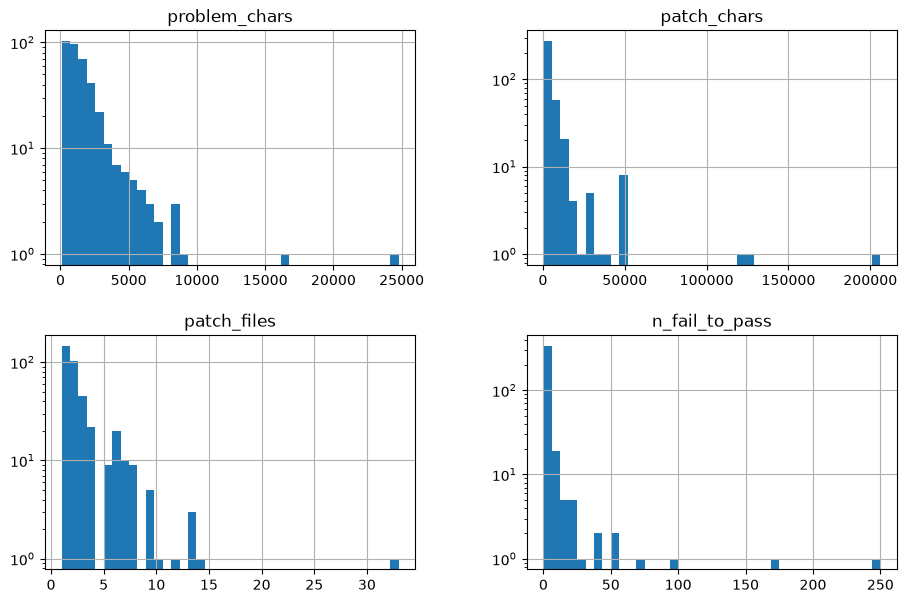

In [29]:
t_rel[["problem_chars", "patch_chars", "patch_files", "n_fail_to_pass"]].hist(
    bins=40, figsize=(11, 7), log=True
);

In [30]:
# 时间关系：related 任务是否确实晚于它引用的 experience 任务？
pairs = (relationship
         .merge(related.drop_duplicates("instance_id")[["instance_id", "created_at"]]
                .rename(columns={"instance_id": "related_instance_id", "created_at": "related_at"}),
                on="related_instance_id", how="left")
         .merge(experience.drop_duplicates("instance_id")[["instance_id", "created_at"]]
                .rename(columns={"instance_id": "experience_instance_id", "created_at": "experience_at"}),
                on="experience_instance_id", how="left"))

pairs["related_at"] = pd.to_datetime(pairs["related_at"], errors="coerce", utc=True)
pairs["experience_at"] = pd.to_datetime(pairs["experience_at"], errors="coerce", utc=True)
pairs["gap_days"] = (pairs["related_at"] - pairs["experience_at"]).dt.days

ok = pairs["gap_days"].notna()
print(f"可比较的配对: {ok.sum()}/{len(pairs)}")
print("related 晚于 experience 的比例:", f"{(pairs.loc[ok, 'gap_days'] > 0).mean():.1%}")
print()
print("时间间隔（天）:")
print(pairs["gap_days"].describe().round(1).to_string())

可比较的配对: 265/376
related 晚于 experience 的比例: 30.9%

时间间隔（天）:
count     265.0
mean     -129.8
std       585.8
min     -2654.0
25%       -97.0
50%         0.0
75%         9.0
max      2189.0


**这个结果有点反直觉，值得留意。**

只有约 31% 的配对里 related 任务的 `created_at` 晚于它的 experience 任务，中位间隔是 0 天。
也就是说，这里的 "prior experience" 指的是 **issue/PR 之间的引用与依赖关系**（谁 reference 了谁），
而**不是**"时间上更早"。两个 issue 常常是同期开的，甚至 experience 那条更晚。

再加上还有 111/376 个配对因为 `created_at` 缺失而无法比较。

如果你要用这个 benchmark 论证"复用历史经验"，需要意识到：它并没有强制一条时间上的因果方向，
所以严格来说存在从"未来"往"过去"泄漏信息的可能。想避免的话，可以用上面的 `gap_days > 0`
自己筛一个时序干净的子集。

## 5. Lite 子集

用来快速实验。确认它就是全量集的子集。

In [31]:
print("experience_lite ⊆ experience :",
      set(experience_lite["instance_id"]).issubset(set(experience["instance_id"])))
print("related_lite    ⊆ related    :",
      set(related_lite["instance_id"]).issubset(set(related["instance_id"])))
print()
print("related_lite 覆盖 repo 数:", related_lite["repo"].nunique())
print(related_lite["repo"].value_counts().head(10).to_string())

# lite 的 related 任务，其经验是否也都在 lite 经验池里？
lite_links = relationship[relationship["related_instance_id"].isin(related_lite["instance_id"])]
covered = set(lite_links["experience_instance_id"]) <= set(experience_lite["instance_id"])
print()
print("related_lite 所需的 experience 全部在 experience_lite 中:", covered)
if not covered:
    n_missing = len(set(lite_links["experience_instance_id"]) - set(experience_lite["instance_id"]))
    print(f"  -> 有 {n_missing} 个所需 experience 只存在于完整经验池中")

experience_lite ⊆ experience : True
related_lite    ⊆ related    : True

related_lite 覆盖 repo 数: 12
repo
django/django                36
sympy/sympy                  26
matplotlib/matplotlib        12
scikit-learn/scikit-learn    10
psf/requests                  3
astropy/astropy               2
mwaskom/seaborn               2
pydata/xarray                 2
pytest-dev/pytest             2
sphinx-doc/sphinx             2

related_lite 所需的 experience 全部在 experience_lite 中: False
  -> 有 1 个所需 experience 只存在于完整经验池中


## 6. 自己挑一个来看

改下面的 `INSTANCE_ID` 就能看任意一条。

In [32]:
INSTANCE_ID = related["instance_id"].iloc[3]   # 换成任意 id

src = related if INSTANCE_ID in set(related["instance_id"]) else experience
show_instance(src.drop_duplicates("instance_id").set_index("instance_id").loc[INSTANCE_ID],
              max_chars=4000)

### repo
django/django

### base_commit
19e67c6cd13d6442abb2a6eba1b7fba80dcf5457

### patch
diff --git a/django/forms/formsets.py b/django/forms/formsets.py
index eafe35720f1e..444c84c9d4f0 100644
--- a/django/forms/formsets.py
+++ b/django/forms/formsets.py
@@ -54,13 +54,14 @@ class BaseFormSet(object):
     A collection of instances of the same Form class.
     """
     def __init__(self, data=None, files=None, auto_id='id_%s', prefix=None,
-                 initial=None, error_class=ErrorList):
+                 initial=None, error_class=ErrorList, form_kwargs=None):
         self.is_bound = data is not None or files is not None
         self.prefix = prefix or self.get_default_prefix()
         self.auto_id = auto_id
         self.data = data or {}
         self.files = files or {}
         self.initial = initial
+        self.form_kwargs = form_kwargs or {}
         self.error_class = error_class
         self._errors = None
         self._non_form_errors = None
@@ -139,9 +140,16 

---

## 附：怎么真正跑评测

本 notebook 只做数据理解。要实际跑 agent 并判分：

- 评测代码：https://github.com/jiayuanz3/SWEContextBench
- 预构建 Docker 镜像（376 个 related 任务）：https://hub.docker.com/r/jiayuanz3/swecontextbench/tags

判分逻辑与 SWE-bench 一致：在 `base_commit` 上应用你生成的 patch，再强制打上官方
`test_patch`，然后跑测试 —— 要求 `FAIL_TO_PASS` 全部通过，且 `PASS_TO_PASS` 不出现回归。

本 benchmark 特有的部分是**两阶段**：先在 experience 池上跑一遍并把过程存成某种可检索的形式，
再在 related 任务上跑，比较不同的上下文策略（无上下文 / 全量塞入 / 检索 / 给定 oracle 经验）
在准确率、耗时、token 消耗上的差异。